# Feature Engineering & Selection Exercise

1. Add robust scaling (using median and interquartile range instead of mean and standard deviation) to the numerical transforms. Compare it to standard scaling on data with extreme outliers.
2. Implement leave-one-out target encoding: for each row, compute the target mean excluding that row's own target value. Show how this reduces overfitting compared to naive target encoding.
3. Build an automated feature selection pipeline that combines variance threshold, correlation filtering, and mutual information ranking. Apply it to the housing dataset and compare model performance (use a simple linear regression) with all features vs selected features.


### 1. Add robust scaling (using median and interquartile range instead of mean and standard deviation) to the numerical transforms. Compare it to standard scaling on data with extreme outliers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import math


def min_max_scale(values):
    min_val = min(values)
    max_val = max(values)
    if max_val == min_val:
        return [0.0] * len(values)
    return [(v - min_val) / (max_val - min_val) for v in values]


def standardize(values):
    n = len(values)
    mean = sum(values) / n
    variance = sum((v - mean) ** 2 for v in values) / n
    std = math.sqrt(variance) if variance > 0 else 1.0
    return [(v - mean) / std for v in values]


def log_transform(values):
    return [math.log(v + 1) for v in values]
    

def bin_values(values, n_bins=5):
    min_val = min(values)
    max_val = max(values)
    bin_width = (max_val - min_val) / n_bins
    if bin_width == 0:
        return [0] * len(values)
    result = []
    for v in values:
        bin_idx = int((v - min_val) / bin_width)
        bin_idx = min(bin_idx, n_bins - 1)
        result.append(bin_idx)
    return result


def polynomial_features(row, degree=2):
    n = len(row)
    result = list(row)
    if degree >= 2:
        for i in range(n):
            result.append(row[i] ** 2)
        for i in range(n):
            for j in range(i + 1, n):
                result.append(row[i] * row[j])
    return result

Original
Mean   : 51.39193792958007
Median : 48.843517176117594
Std    : 43.15747756902654
IQR    : 11.149740453427526

StandardScaler
Mean : -2.0301221021717148e-16
Std  : 0.9999999999999999

RobustScaler
Median : 0.0
IQR    : 1.0


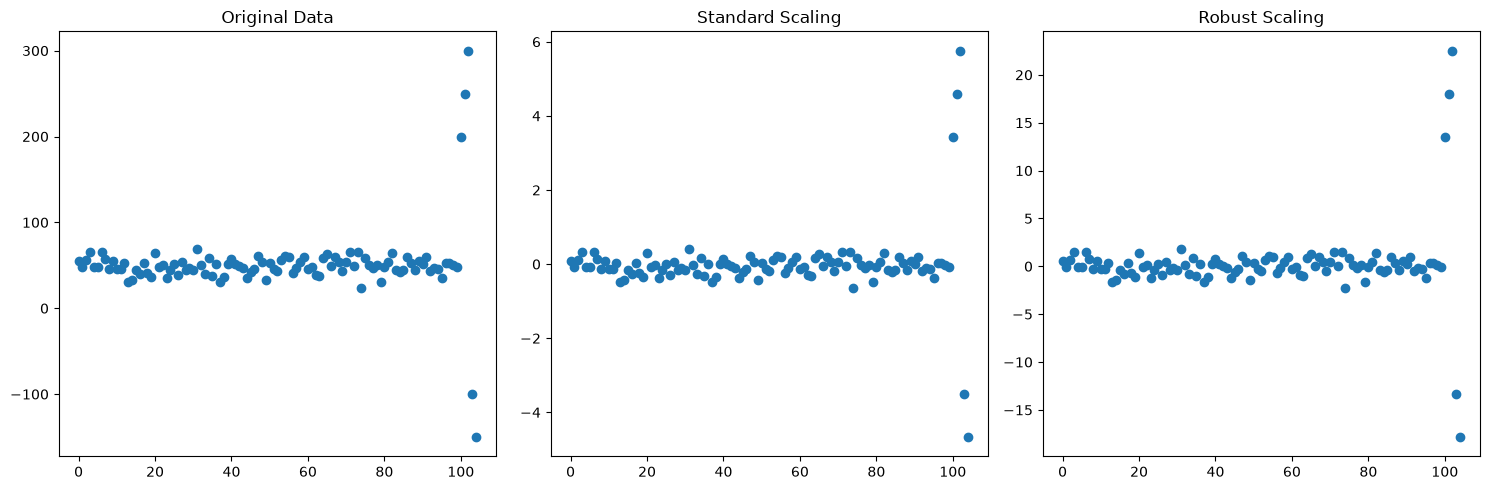

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler

# -----------------------------
# Generate data
# -----------------------------
np.random.seed(42)

# Normal data
X = np.random.normal(loc=50, scale=10, size=(100, 1))

# Add extreme outliers
outliers = np.array([[200], [250], [300], [-100], [-150]])

X_outlier = np.vstack([X, outliers])

# -----------------------------
# Scaling
# -----------------------------
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()  # median + IQR

X_standard = standard_scaler.fit_transform(X_outlier)
X_robust = robust_scaler.fit_transform(X_outlier)

# -----------------------------
# Statistics
# -----------------------------
print("Original")
print("Mean   :", np.mean(X_outlier))
print("Median :", np.median(X_outlier))
print("Std    :", np.std(X_outlier))
print("IQR    :", np.percentile(X_outlier, 75) - np.percentile(X_outlier, 25))

print("\nStandardScaler")
print("Mean :", np.mean(X_standard))
print("Std  :", np.std(X_standard))

print("\nRobustScaler")
print("Median :", np.median(X_robust))
print("IQR    :", np.percentile(X_robust, 75) - np.percentile(X_robust, 25))

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(np.arange(len(X_outlier)), X_outlier)
axes[0].set_title("Original Data")

axes[1].scatter(np.arange(len(X_standard)), X_standard)
axes[1].set_title("Standard Scaling")

axes[2].scatter(np.arange(len(X_robust)), X_robust)
axes[2].set_title("Robust Scaling")

plt.tight_layout()
plt.show()

In [9]:
def robust_scale(values):
    values_sorted = sorted(values)
    n = len(values_sorted)

    # Median
    if n % 2 == 0:
        median = (values_sorted[n // 2 - 1] + values_sorted[n // 2]) / 2
    else:
        median = values_sorted[n // 2]

    q1 = values_sorted[n // 4]
    q3 = values_sorted[(3 * n) // 4]

    iqr = q3 - q1
    if iqr == 0:
        iqr = 1.0

    print("q1 : ", q1)
    print("q3 : ", q3)
    print("iqr : ", iqr)

    return [(v - median) / iqr for v in values]




In [10]:
robust_scale([1,256,7678,8978])

q1 :  256
q3 :  8978
iqr :  8722


[-0.45471222196743866,
 -0.4254758083008484,
 0.4254758083008484,
 0.5745241916991516]

q1 :  43
q3 :  56
iqr :  13
Original:
[60, 43, 40, 48, 47, 47, 44, 43, 57, 42]

Standard Scaled:
[0.21, -0.18, -0.25, -0.06, -0.09, -0.09, -0.16, -0.18, 0.14, -0.2]

Robust Scaled:
[0.92, -0.38, -0.62, 0.0, -0.08, -0.08, -0.31, -0.38, 0.69, -0.46]


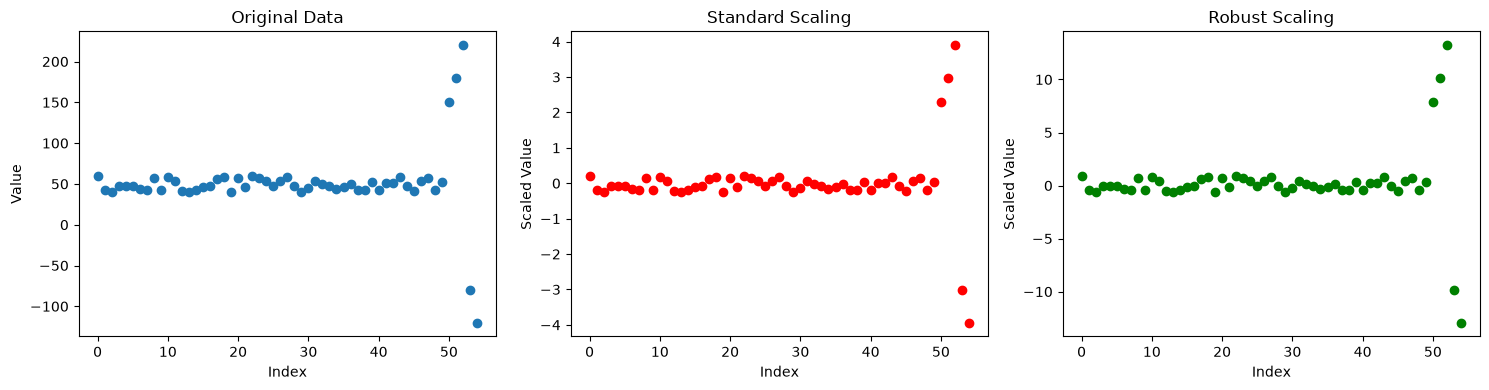

In [11]:
import random
import matplotlib.pyplot as plt

# -----------------------
# Dummy data
# -----------------------
random.seed(42)

# Normal values
data = [random.randint(40, 60) for _ in range(50)]

# Add extreme outliers
data.extend([150, 180, 220, -80, -120])

# -----------------------
# Apply scaling
# -----------------------
standard_scaled = standardize(data)
robust_scaled = robust_scale(data)

# -----------------------
# Print first few values
# -----------------------
print("Original:")
print(data[:10])

print("\nStandard Scaled:")
print([round(x, 2) for x in standard_scaled[:10]])

print("\nRobust Scaled:")
print([round(x, 2) for x in robust_scaled[:10]])

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(range(len(data)), data)
plt.title("Original Data")
plt.xlabel("Index")
plt.ylabel("Value")

plt.subplot(1, 3, 2)
plt.scatter(range(len(standard_scaled)), standard_scaled, color="red")
plt.title("Standard Scaling")
plt.xlabel("Index")
plt.ylabel("Scaled Value")

plt.subplot(1, 3, 3)
plt.scatter(range(len(robust_scaled)), robust_scaled, color="green")
plt.title("Robust Scaling")
plt.xlabel("Index")
plt.ylabel("Scaled Value")

plt.tight_layout()
plt.show()

### 2. Implement leave-one-out target encoding: for each row, compute the target mean excluding that row's own target value. Show how this reduces overfitting compared to naive target encoding.

In [17]:
from sklearn.preprocessing import OneHotEncoder ,TargetEncoder

In [35]:
import pandas as pd

df = pd.DataFrame({
    "City": ["A", "A", "A", "B", "B"],
    "Target": [1, 0, 1, 0, 1]
})

# Naive
df["Naive"] = df.groupby("City")["Target"].transform("mean")

# Leave-One-Out
loo = []

for i in range(len(df)):
    city = df.loc[i, "City"]

    # Same city except current row
    others = df[(df["City"] == city) & (df.index != i)]["Target"]

    loo.append(others.mean())

df["LOO"] = loo

print(df)

  City  Target     Naive  LOO
0    A       1  0.666667  0.5
1    A       0  0.666667  1.0
2    A       1  0.666667  0.5
3    B       0  0.500000  1.0
4    B       1  0.500000  0.0


### 3. Build an automated feature selection pipeline that combines variance threshold, correlation filtering, and mutual information ranking. Apply it to the housing dataset and compare model performance (use a simple linear regression) with all features vs selected features.

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing

In [39]:
housing = fetch_california_housing()

In [41]:
X=housing["data"]
y=housing["target"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [46]:
#  without feature selection pipe line
ln = LinearRegression()

In [47]:
ln.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.44, 0.01,-0.11,...,-0. ,-0.42,-0.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-36.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[162693.6 , 1731.79, 1484.89,..., 247.74, 71.82, 25.06]"


In [48]:
print("Default Score " ,ln.score(X_test,y_test))


Default Score  0.6014460797890688


Default Score : 0.6014460797890688

In [52]:
# with feature selection pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold , mutual_info_regression
from sklearn.metrics import r2_score

In [55]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

In [53]:
vt = VarianceThreshold(threshold=0.01)

In [56]:
X_var=pd.DataFrame(
    vt.fit_transform(X),
    columns=X.columns[vt.get_support()]
)

In [57]:
print("After Variance Threshold")
print(X_var.columns.tolist())


After Variance Threshold
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


1 tao to bad jaini :) 

In [62]:
# -----------------------------
# 2. Correlation Filtering
# -----------------------------
corr = X_var.corr().abs()


In [61]:

# -----------------------------
# 2. Correlation Filtering
# -----------------------------
corr = X_var.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

drop_cols = [
    col for col in upper.columns
    if any(upper[col] > 0.90)
]

X_corr = X_var.drop(columns=drop_cols)

print("\nDropped Correlated Features")
print(drop_cols)


Dropped Correlated Features
['Longitude']


In [65]:

print("\nRemaining Features")
print(X_corr.columns.tolist())



Remaining Features
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude']


In [66]:

# -----------------------------
# 3. Mutual Information Ranking
# -----------------------------
mi = mutual_info_regression(X_corr, y, random_state=42)

mi_scores = pd.Series(mi, index=X_corr.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("\nMutual Information Scores")
print(mi_scores)



Mutual Information Scores
MedInc        0.387517
Latitude      0.371727
AveRooms      0.103225
AveOccup      0.073314
HouseAge      0.032665
AveBedrms     0.024234
Population    0.021617
dtype: float64


In [67]:
# Keep Top 5 Features
selected_features = mi_scores.head(5).index.tolist()

X_selected = X_corr[selected_features]

print("\nSelected Features")
print(selected_features)


Selected Features
['MedInc', 'Latitude', 'AveRooms', 'AveOccup', 'HouseAge']


In [68]:

# -----------------------------
# Model using ALL features
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train, y_train)

pred_all = model_all.predict(X_test)

r2_all = r2_score(y_test, pred_all)

In [69]:

# -----------------------------
# Model using SELECTED features
# -----------------------------
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

model_selected = LinearRegression()
model_selected.fit(X_train2, y_train2)

pred_selected = model_selected.predict(X_test2)

r2_selected = r2_score(y_test2, pred_selected)

In [70]:

# -----------------------------
# Results
# -----------------------------
print("\n===========================")
print("Linear Regression Results")
print("===========================")

print(f"All Features R²      : {r2_all:.4f}")
print(f"Selected Features R² : {r2_selected:.4f}")

if r2_selected >= r2_all:
    print("\nFeature selection improved or maintained performance.")
else:
    print("\nSlight performance drop, but model simpler and uses fewer features.")


Linear Regression Results
All Features R²      : 0.5758
Selected Features R² : 0.5055

Slight performance drop, but model simpler and uses fewer features.
